# Canonical Wang-compatible EEGMMIDB full-cohort run

This is the executable Phase A/B baseline for the approximate-MAC study. It validates 735 EDF recordings for 105 subjects (IDs 1–109, excluding 88, 92, 100 and 104), constructs 8,820 balanced three-second windows, and trains the released EEGNet-8,2 configuration for 100 epochs in each of five subject-disjoint folds. Each fold uses 84 training and 21 held-out subjects. No hyperparameter is chosen to approach the paper’s 65.07% reference.

The code below installs `pyedflib` if needed, verifies the GPU, fetches the EDFs, creates subject caches, trains the folds, and writes predictions, accuracy, macro-F1, checkpoints, and two figures. The subject caches and epoch-10 checkpoints are kept under `/kaggle/working` so this saved Kaggle version retains them. Raw EDFs stay in `/kaggle/temp` to avoid saving 1.75 GB of public source files. The final report includes all five fold rows, mean ± sample standard deviation, and pooled out-of-fold metrics.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 75.6 MB/s eta 0:00:00
GPU: Tesla T4 | PyTorch: 2.10.0+cu128 | pyedflib: 0.1.42
Validated EDFs: 100/735
Validated EDFs: 200/735
Validated EDFs: 300/735
Validated EDFs: 400/735
Validated EDFs: 500/735
Validated EDFs: 600/735
Validated EDFs: 700/735
Validated EDFs: 735/735
Acquisition complete: 735 EDFs, 1,749,996,960 bytes, 20.3s
Processed/cached subjects: 10/105; cache hits=0
Processed/cached subjects: 20/105; cache hits=0
Processed/cached subjects: 30/105; cache hits=0
Processed/cached subjects: 40/105; cache hits=0
Processed/cached subjects: 50/105; cache hits=0
Processed/cached subjects: 60/105; cache hits=0
Processed/cached subjects: 70/105; cache hits=0
Processed/cached subjects: 80/105; cache hits=0
Processed/cached subjects: 90/105; cache hits=0
Processed/cached subjects: 100/105; cache hits=0
Processed/cached subjects: 105/105; cache hits=0
Dataset windows: 8820 | class totals: [2205, 2205, 2205, 2205] | expected exclusions:

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:548: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv2d(


FOLD 0 epoch 1/100 train_acc=0.4637
FOLD 0 epoch 10/100 train_acc=0.5760
FOLD 0 epoch 20/100 train_acc=0.5784
FOLD 0 epoch 30/100 train_acc=0.6655
FOLD 0 epoch 40/100 train_acc=0.6746
FOLD 0 epoch 50/100 train_acc=0.6838
FOLD 0 epoch 60/100 train_acc=0.7038
FOLD 0 epoch 70/100 train_acc=0.7003
FOLD 0 epoch 80/100 train_acc=0.7073
FOLD 0 epoch 90/100 train_acc=0.7088
FOLD 0 epoch 100/100 train_acc=0.7028
Completed fold 0: accuracy=60.71% macro-F1=60.76%
FOLD 1 epoch 1/100 train_acc=0.4277
FOLD 1 epoch 10/100 train_acc=0.5502
FOLD 1 epoch 20/100 train_acc=0.5632
FOLD 1 epoch 30/100 train_acc=0.6542
FOLD 1 epoch 40/100 train_acc=0.6550
FOLD 1 epoch 50/100 train_acc=0.6643
FOLD 1 epoch 60/100 train_acc=0.6845
FOLD 1 epoch 70/100 train_acc=0.6854
FOLD 1 epoch 80/100 train_acc=0.6814
FOLD 1 epoch 90/100 train_acc=0.6848
FOLD 1 epoch 100/100 train_acc=0.6841
Completed fold 1: accuracy=69.56% macro-F1=69.51%
FOLD 2 epoch 1/100 train_acc=0.4418
FOLD 2 epoch 10/100 train_acc=0.5601
FOLD 2 epoch 

,fold,accuracy_pct,macro_f1_pct,n_validation
0,0,60.71,60.76,1764
1,1,69.56,69.51,1764
2,2,65.36,65.43,1764
3,3,63.32,63.44,1764
4,4,66.55,66.49,1764


Mean ± sample SD accuracy: 65.10 ± 3.33% | macro-F1: 65.13 ± 3.28%
Pooled OOF accuracy/F1: 65.10% / 65.13% | mean deviation from 65.07%: +0.03 pp | verdict: verified_within_band
Saved metrics/checkpoints/cache: /kaggle/working/canonical_full_cohort | summary: /kaggle/working/canonical_full_cohort/canonical_full_cohort_summary.json


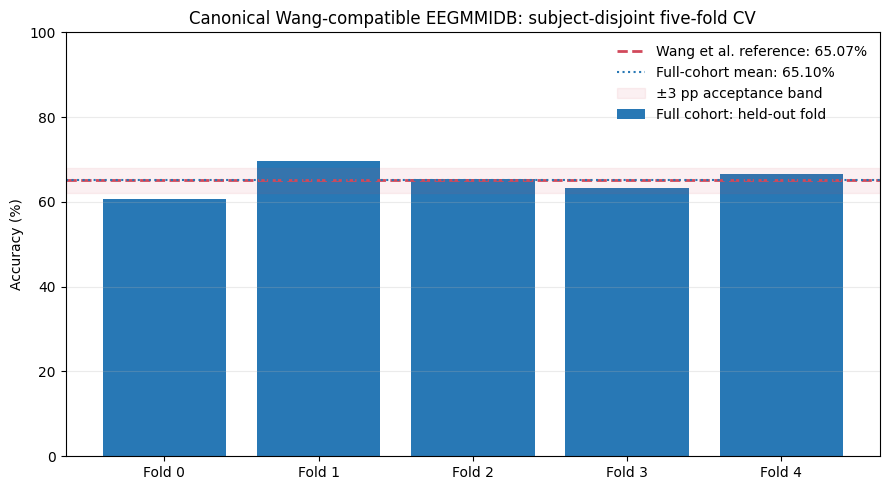

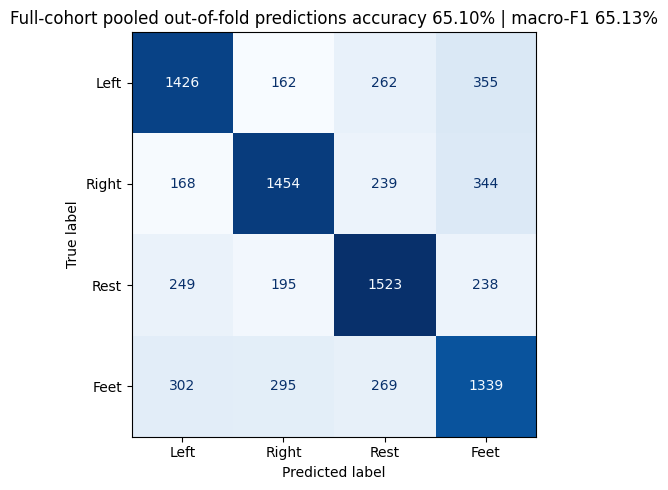

In [1]:
# Canonical Wang-compatible full-cohort baseline: acquisition, exact preprocessing, 5-fold training, evaluation, and figures.
# Run this cell only. It is restart-safe: subject windows are cached and completed folds are skipped.
import sys, subprocess, importlib.util, os, json, random, time, hashlib, warnings
from pathlib import Path
from datetime import datetime, timezone
from concurrent.futures import ThreadPoolExecutor, as_completed

if importlib.util.find_spec('pyedflib') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'pyedflib'])
import boto3, numpy as np, pandas as pd, torch, pyedflib
import matplotlib.pyplot as plt
from botocore import UNSIGNED
from botocore.config import Config
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

assert torch.cuda.is_available(), 'Select a Kaggle GPU accelerator (T4 recommended) before running this cell.'
device = torch.device('cuda')
print('GPU:', torch.cuda.get_device_name(0), '| PyTorch:', torch.__version__, '| pyedflib:', pyedflib.__version__)

# These exclusions are copied from the released Wang get_data.py loader.
EXCLUDED = {88, 92, 100, 104}
SUBJECTS = [s for s in range(1, 110) if s not in EXCLUDED]
RUNS = (1, 4, 6, 8, 10, 12, 14)
assert len(SUBJECTS) == 105 and len(RUNS) * len(SUBJECTS) == 735
BASE = Path('/kaggle/working/eeg_axmac_wang_full_cohort')
RAW = Path('/kaggle/temp/eeg_axmac_wang_full_cohort/raw/MNE-eegbci-data/files/eegmmidb/1.0.0')
CACHE = BASE / 'subject_cache'
OUT = Path('/kaggle/working/canonical_full_cohort')
for folder in (RAW, CACHE, OUT): folder.mkdir(parents=True, exist_ok=True)

# Fetch only the official cohort files from the public PhysioNet S3 mirror; validate EDF headers and sizes.
s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED, max_pool_connections=36,
    connect_timeout=20, read_timeout=120, retries={'max_attempts': 5}))
def valid_edf(p):
    try:
        return p.is_file() and p.stat().st_size > 100_000 and p.open('rb').read(1) == b'0'
    except OSError: return False
def fetch(job):
    subject, run = job
    folder = RAW / f'S{subject:03d}'; folder.mkdir(parents=True, exist_ok=True)
    target = folder / f'S{subject:03d}R{run:02d}.edf'
    if valid_edf(target): return target
    key = f'eegmmidb/1.0.0/S{subject:03d}/S{subject:03d}R{run:02d}.edf'
    part = target.with_suffix('.edf.part')
    try:
        s3.download_file('physionet-open', key, str(part))
        if not valid_edf(part): raise IOError(f'Invalid EDF download: {key}')
        part.replace(target)
    except Exception:
        part.unlink(missing_ok=True); raise
    return target
jobs = [(s, r) for s in SUBJECTS for r in RUNS]
t0 = time.time(); done = 0
with ThreadPoolExecutor(max_workers=32) as pool:
    futures = [pool.submit(fetch, job) for job in jobs]
    for fut in as_completed(futures):
        fut.result(); done += 1
        if done % 100 == 0 or done == len(jobs): print(f'Validated EDFs: {done}/{len(jobs)}', flush=True)
assert all(valid_edf(RAW/f'S{s:03d}'/f'S{s:03d}R{r:02d}.edf') for s,r in jobs)
print(f'Acquisition complete: {len(jobs)} EDFs, {sum((RAW/f"S{s:03d}"/f"S{s:03d}R{r:02d}.edf").stat().st_size for s,r in jobs):,} bytes, {time.time()-t0:.1f}s')

# Extract exactly 3-s raw (unfiltered) windows: runs 1/4/6/8/10/12/14, annotation order, 7 event caps.
# The released code's extra run-1 window uses Python's unseeded RNG; random.Random(7) makes it reproducible.
FS, NS = 160, 480
def load_subject(subject):
    cache_file = CACHE / f'S{subject:03d}.npz'
    if cache_file.exists():
        with np.load(cache_file, allow_pickle=False) as z:
            x, y = z['x'], z['y']
        if x.shape == (84,64,1,480) and np.array_equal(np.bincount(y,minlength=4), [21,21,21,21]):
            return x.astype(np.float32, copy=False), y.astype(np.int64, copy=False), True
    xs, ys = [], []
    for run in RUNS:
        path = RAW/f'S{subject:03d}'/f'S{subject:03d}R{run:02d}.edf'
        reader = pyedflib.EdfReader(str(path))
        try:
            fs = int(reader.getSampleFrequency(0))
            if fs != FS or reader.signals_in_file < 64: raise ValueError(f'Unexpected EDF metadata: {path}')
            signal = np.stack([reader.readSignal(ch) for ch in range(64)]).astype(np.float32)
            onsets, _, desc = reader.readAnnotations()
            labels = [d.decode(errors='ignore') if isinstance(d, bytes) else str(d) for d in desc]
        finally: reader.close()
        if run == 1:
            for w in range(20): xs.append(signal[:,w*NS:(w+1)*NS]); ys.append(2)
            start = random.Random(7).randint(0,57*fs)
            if start+NS > signal.shape[1]: raise ValueError(f'Extra rest window outside recording: {path}')
            xs.append(signal[:,start:start+NS]); ys.append(2)
            continue
        counts = {'T1':0,'T2':0}
        for label,onset in zip(labels,onsets):
            start = int(fs*float(onset)); epoch = signal[:,start:start+NS]
            if epoch.shape[1] != NS: continue
            if run in (4,8,12) and label in ('T1','T2') and counts[label] < 7:
                xs.append(epoch); ys.append(0 if label=='T1' else 1); counts[label]+=1
            elif run in (6,10,14) and label=='T2' and counts['T2'] < 7:
                xs.append(epoch); ys.append(3); counts['T2']+=1
    x = np.stack(xs).astype(np.float32)[:,:,None,:]; y = np.asarray(ys,dtype=np.int64)
    counts = np.bincount(y,minlength=4)
    if x.shape != (84,64,1,480) or not np.array_equal(counts,[21,21,21,21]) or not np.isfinite(x).all():
        raise ValueError(f'Subject {subject} violates Wang cohort balance: X={x.shape}, labels={counts.tolist()}')
    np.savez_compressed(cache_file,x=x,y=y)
    return x,y,False

per_subject = {}; cache_hits=0
for i,subject in enumerate(SUBJECTS,1):
    x,y,hit=load_subject(subject); per_subject[subject]=(x,y); cache_hits+=hit
    if i % 10 == 0 or i == len(SUBJECTS): print(f'Processed/cached subjects: {i}/{len(SUBJECTS)}; cache hits={cache_hits}',flush=True)
assert set(per_subject)==set(SUBJECTS)
print('Dataset windows:',len(SUBJECTS)*84,'| class totals:',np.sum([np.bincount(per_subject[s][1],minlength=4) for s in SUBJECTS],axis=0).tolist(),
      '| expected exclusions:',sorted(EXCLUDED))

# Reproduce local random.Random(42) subject-disjoint fold construction: 84 train and 21 held-out people.
shuffled=SUBJECTS.copy(); random.Random(42).shuffle(shuffled)
folds=[]; start=0
for fold in range(5):
    val_ids=shuffled[start:start+21]; start+=21; valset=set(val_ids)
    train_ids=[s for s in SUBJECTS if s not in valset]
    assert len(train_ids)==84 and len(val_ids)==21 and set(train_ids).isdisjoint(val_ids)
    folds.append((train_ids,val_ids))
print('Fold held-out subject IDs:',[v for _,v in folds])

# Wang EEGNet-8,2: kernel 128, F1=8, D=2, F2=16, pool 8×8, ELU, dropout .2.
# Match released BatchNormalization(axis=1); project spatial and classifier max-norms after each update.
class PaperAlignedEEGNet82(nn.Module):
    def __init__(self):
        super().__init__()
        self.temporal=nn.Conv2d(1,8,(1,128),padding='same',bias=False)
        self.bn1=nn.BatchNorm2d(64)
        self.spatial=nn.Conv2d(8,16,(64,1),groups=8,bias=False)
        self.bn2=nn.BatchNorm2d(1)
        self.pool1=nn.AvgPool2d((1,8)); self.drop1=nn.Dropout(.2)
        self.sep_depth=nn.Conv2d(16,16,(1,16),padding='same',groups=16,bias=False)
        self.sep_point=nn.Conv2d(16,16,1,bias=False); self.bn3=nn.BatchNorm2d(1)
        self.pool2=nn.AvgPool2d((1,8)); self.drop2=nn.Dropout(.2)
        self.classifier=nn.Linear(16*7,4)
    @torch.no_grad()
    def constrain(self):
        for weight,limit,axis in ((self.spatial.weight,1.0,(1,2,3)),(self.classifier.weight,.25,(1,))):
            norm=torch.linalg.vector_norm(weight,ord=2,dim=axis,keepdim=True).clamp_min(1e-12)
            weight.mul_(torch.clamp(limit/norm,max=1.0))
    def forward(self,x):
        x=self.temporal(x.transpose(1,2))
        x=self.bn1(x.transpose(1,2)).transpose(1,2)
        x=self.spatial(x); x=self.bn2(x.transpose(1,2)).transpose(1,2)
        x=self.drop1(self.pool1(torch.nn.functional.elu(x)))
        x=self.sep_point(self.sep_depth(x)); x=self.bn3(x.transpose(1,2)).transpose(1,2)
        x=self.drop2(self.pool2(torch.nn.functional.elu(x)))
        return self.classifier(x.flatten(1))

def train_one_fold(fold):
    result_path=OUT/f'canonical_full_cohort_fold{fold}_result.json'
    if result_path.exists(): return json.loads(result_path.read_text())
    train_ids,val_ids=folds[fold]
    xtr=np.concatenate([per_subject[s][0] for s in train_ids]); ytr=np.concatenate([per_subject[s][1] for s in train_ids])
    xva=np.concatenate([per_subject[s][0] for s in val_ids]); yva=np.concatenate([per_subject[s][1] for s in val_ids])
    assert len(ytr)==7056 and len(yva)==1764
    seed=42+fold; random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark=False
    model=PaperAlignedEEGNet82().to(device); optimizer=torch.optim.Adam(model.parameters(),lr=.01)
    criterion=nn.CrossEntropyLoss(); run=f'canonical_full_cohort_fold{fold}'
    ckpt=OUT/f'{run}_checkpoint.pt'; history=[]; first=1
    if ckpt.exists():
        saved=torch.load(ckpt,map_location='cpu',weights_only=False)
        if saved.get('run_id')=='canonical_full_cohort_20260926' and saved.get('fold')==fold:
            model.load_state_dict(saved['model']); optimizer.load_state_dict(saved['optimizer'])
            history=saved['history']; first=saved['epoch']+1
            print(f'Resuming fold {fold} at epoch {first}',flush=True)
    xt=torch.from_numpy(xtr); yt=torch.from_numpy(ytr)
    for epoch in range(first,101):
        lr=.01 if epoch<=20 else (.001 if epoch<=50 else .0001)
        for group in optimizer.param_groups: group['lr']=lr
        loader=DataLoader(TensorDataset(xt,yt),batch_size=16,shuffle=True,num_workers=0,pin_memory=True,
                          generator=torch.Generator().manual_seed(seed*1000+epoch))
        model.train(); loss_sum=0.; correct=0
        for xb,yb in loader:
            xb=xb.to(device,non_blocking=True); yb=yb.to(device,non_blocking=True)
            optimizer.zero_grad(set_to_none=True); logits=model(xb); loss=criterion(logits,yb)
            loss.backward(); optimizer.step(); model.constrain()
            loss_sum+=loss.item()*len(yb); correct+=(logits.argmax(1)==yb).sum().item()
        history.append({'epoch':epoch,'lr':lr,'train_loss':loss_sum/len(ytr),'train_accuracy':correct/len(ytr)})
        if epoch==1 or epoch%10==0:
            print(f'FOLD {fold} epoch {epoch}/100 train_acc={history[-1]["train_accuracy"]:.4f}',flush=True)
        if epoch%10==0:
            torch.save({'run_id':'canonical_full_cohort_20260926','fold':fold,'epoch':epoch,
                'model':model.state_dict(),'optimizer':optimizer.state_dict(),'history':history},ckpt)
            pd.DataFrame(history).to_csv(OUT/f'{run}_history.csv',index=False)
    model.eval(); preds=[]
    with torch.no_grad():
        for batch in torch.from_numpy(xva).split(128): preds.extend(model(batch.to(device)).argmax(1).cpu().numpy().tolist())
    pred=np.asarray(preds,dtype=np.int64)
    row={'tag':'canonical_full_cohort','run_id':'canonical_full_cohort_20260926','timestamp_utc':datetime.now(timezone.utc).isoformat(),
        'dataset':'EEGMMIDB','protocol':'Wang released data construction; subject-disjoint 5-fold CV','fold':fold,
        'train_subjects':train_ids,'validation_subjects':val_ids,'n_train':len(ytr),'n_validation':len(yva),
        'accuracy':float(accuracy_score(yva,pred)),'macro_f1':float(f1_score(yva,pred,average='macro',zero_division=0)),
        'reference_accuracy':.6507,'delta_pp':float((accuracy_score(yva,pred)-.6507)*100),
        'baseline_status':'fold_metric','epochs':100,'batch_size':16,'seed':seed,
        'exclusions':'88,92,100,104','notes':'Raw 64x480 windows; deterministic seed-7 replacement for released unseeded Python extra-rest RNG.'}
    pd.DataFrame({'true':yva,'pred':pred}).to_csv(OUT/f'{run}_predictions.csv',index=False)
    torch.save({'model':model.state_dict(),'fold':fold,'run_id':row['run_id']},OUT/f'{run}_model.pt')
    result_path.write_text(json.dumps(row,indent=2),encoding='utf-8')
    return row

rows=[]; total_start=time.time()
for fold in range(5):
    row=train_one_fold(fold); rows.append(row)
    print(f'Completed fold {fold}: accuracy={row["accuracy"]*100:.2f}% macro-F1={row["macro_f1"]*100:.2f}%',flush=True)
fold_df=pd.DataFrame(rows).sort_values('fold').reset_index(drop=True)
acc_mean=float(fold_df.accuracy.mean()); acc_std=float(fold_df.accuracy.std(ddof=1))
f1_mean=float(fold_df.macro_f1.mean()); f1_std=float(fold_df.macro_f1.std(ddof=1))
all_true=np.concatenate([pd.read_csv(OUT/f'canonical_full_cohort_fold{f}_predictions.csv').true.to_numpy() for f in range(5)])
all_pred=np.concatenate([pd.read_csv(OUT/f'canonical_full_cohort_fold{f}_predictions.csv').pred.to_numpy() for f in range(5)])
pooled_acc=float(accuracy_score(all_true,all_pred)); pooled_f1=float(f1_score(all_true,all_pred,average='macro',zero_division=0))
verdict='verified_within_band' if abs((acc_mean-.6507)*100)<=3 else 'outside_±3pp_investigate_protocol'
summary={'tag':'canonical_full_cohort','run_id':'canonical_full_cohort_20260926','timestamp_utc':datetime.now(timezone.utc).isoformat(),
 'n_subjects':105,'exclusions':sorted(EXCLUDED),'folds':5,'epochs':100,'fold_accuracy_mean':acc_mean,'fold_accuracy_std_sample':acc_std,
 'fold_macro_f1_mean':f1_mean,'fold_macro_f1_std_sample':f1_std,'pooled_oof_accuracy':pooled_acc,'pooled_oof_macro_f1':pooled_f1,
 'reference_accuracy':.6507,'delta_mean_pp':(acc_mean-.6507)*100,'verdict':verdict,'elapsed_seconds':time.time()-total_start}
(OUT/'canonical_full_cohort_summary.json').write_text(json.dumps(summary,indent=2),encoding='utf-8')
fold_df.to_csv(OUT/'canonical_full_cohort_fold_metrics.csv',index=False)
summary_row={'tag':'canonical_full_cohort','run_id':summary['run_id'],'dataset':'EEGMMIDB','model':'Wang EEGNet-8,2','n_classes':4,'mode':'global',
 'fold':'mean ± sample std','accuracy':acc_mean,'accuracy_std':acc_std,'macro_f1':f1_mean,'macro_f1_std':f1_std,
 'pooled_oof_accuracy':pooled_acc,'pooled_oof_macro_f1':pooled_f1,'published_reference_accuracy':.6507,
 'delta_vs_published_pp':(acc_mean-.6507)*100,'baseline_status':verdict,'protocol':'raw Wang extraction + subject-disjoint 5-fold CV',
 'exclusions':'88,92,100,104','timestamp_utc':summary['timestamp_utc']}
report=pd.concat([fold_df.assign(model='Wang EEGNet-8,2',n_classes=4,mode='global'),pd.DataFrame([summary_row])],ignore_index=True)
report.to_csv(OUT/'baseline_accuracy_report.csv',index=False)
print()
print('FULL COHORT FOLD TABLE')
display(fold_df[['fold','accuracy','macro_f1','n_validation']].assign(accuracy_pct=lambda d:d.accuracy*100,macro_f1_pct=lambda d:d.macro_f1*100)[['fold','accuracy_pct','macro_f1_pct','n_validation']].round(2))
print(f"Mean ± sample SD accuracy: {acc_mean*100:.2f} ± {acc_std*100:.2f}% | macro-F1: {f1_mean*100:.2f} ± {f1_std*100:.2f}%")
print(f'Pooled OOF accuracy/F1: {pooled_acc*100:.2f}% / {pooled_f1*100:.2f}% | mean deviation from 65.07%: {(acc_mean-.6507)*100:+.2f} pp | verdict: {verdict}')
print('Saved metrics/checkpoints/cache:',OUT,'| summary:',OUT/'canonical_full_cohort_summary.json')
# Paper-ready fold plot with reference and the previously completed medium-scale estimate.
fig,ax=plt.subplots(figsize=(9,5)); xx=np.arange(5)
ax.bar(xx,fold_df.accuracy*100,color='#2878B5',label='Full cohort: held-out fold')
ax.axhline(65.07,color='#D1495B',linestyle='--',linewidth=2,label='Wang et al. reference: 65.07%')
ax.axhline(acc_mean*100,color='#2878B5',linestyle=':',label=f'Full-cohort mean: {acc_mean*100:.2f}%')
ax.axhspan(62.07,68.07,color='#D1495B',alpha=.08,label='±3 pp acceptance band')
ax.set(xticks=xx,xticklabels=[f'Fold {i}' for i in range(5)],ylabel='Accuracy (%)',title='Canonical Wang-compatible EEGMMIDB: subject-disjoint five-fold CV')
ax.set_ylim(0,100); ax.grid(axis='y',alpha=.25); ax.legend(frameon=False,loc='best'); fig.tight_layout()
fig.savefig(OUT/'canonical_full_cohort_fold_accuracy.png',dpi=220,bbox_inches='tight'); plt.show()
fig,ax=plt.subplots(figsize=(7,5)); ConfusionMatrixDisplay(confusion_matrix(all_true,all_pred),display_labels=['Left','Right','Rest','Feet']).plot(ax=ax,cmap='Blues',colorbar=False,values_format='d')
ax.set_title(f'Full-cohort pooled out-of-fold predictions accuracy {pooled_acc*100:.2f}% | macro-F1 {pooled_f1*100:.2f}%'); fig.tight_layout()
fig.savefig(OUT/'canonical_full_cohort_oof_confusion.png',dpi=220,bbox_inches='tight'); plt.show()
